# EDA 09: DepMap Sample Info (the identity spine hub)

## Purpose

`9_DepMap_sample_info.csv` is the **master catalogue** — one row per cell line, and the hub every
other primary file ultimately joins to. Its `DepMap_ID` is the same identifier as `ModelID`
elsewhere; `docs/PROJECT_ARCHITECTURE.md` §2 flags this file specifically as carrying the
**legacy DepMap schema** (`DepMap_ID`, `lineage`, `primary_disease`) retired after 22Q1, while
files 5/8/15/16/17 use the modern schema (`ModelID`, `OncotreeLineage`) — reconciling that mismatch
is notebook 17's job. This notebook establishes the spine itself and how completely every other
primary layer covers it.

**Source, release, grain:** legacy DepMap sample catalogue. One row per cell line, 1,840 rows.

## Questions this notebook must answer

1. Is `DepMap_ID` unique, and which columns are populated well enough to keep?
2. What is the lineage and disease composition of the catalogue — the denominator every coverage
   percentage in notebooks 01–08 was measured against?
3. What clinical metadata (primary vs. metastasis, sex, growth pattern) exists that could confound
   a naive pan-cancer comparison?
4. How completely does each other primary omics layer (RNA, fusions, mutations, genome signatures)
   cover this spine, and does that coverage vary by lineage?

**Interpretation rule:** this table defines who exists in the catalogue — it is the denominator, not
a measurement. Every `not_assayed` state reported in notebooks 01–08 is relative to being present
here first.

## Column dictionary (selected)

| Column | Meaning | Notes |
|---|---|---|
| `DepMap_ID` | legacy DepMap identity key | identical concept to `ModelID` elsewhere — the join hub |
| `lineage` | tissue of origin | legacy schema; `OncotreeLineage` is the modern equivalent (file 17) |
| `primary_disease` | cancer type | |
| `RRID` | Cellosaurus accession | bridges to file 7 |
| `primary_or_metastasis` | sample origin | a confound for cross-line comparisons if not accounted for |
| `sex` | donor sex | |
| `default_growth_pattern` | adherent / suspension / etc. | a QC/culture-condition confound |

## 1. Basic data contract and column completeness

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'
GENE_PROPERTIES = ROOT / 'data' / 'raw' / 'gene_properties'
NON_GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'non_gene_expression'

In [2]:
df = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv')
print(f"Rows (cell lines) : {len(df)}")
print(f"Unique DepMap_ID  : {df['DepMap_ID'].nunique()}")

Rows (cell lines) : 1840
Unique DepMap_ID  : 1840


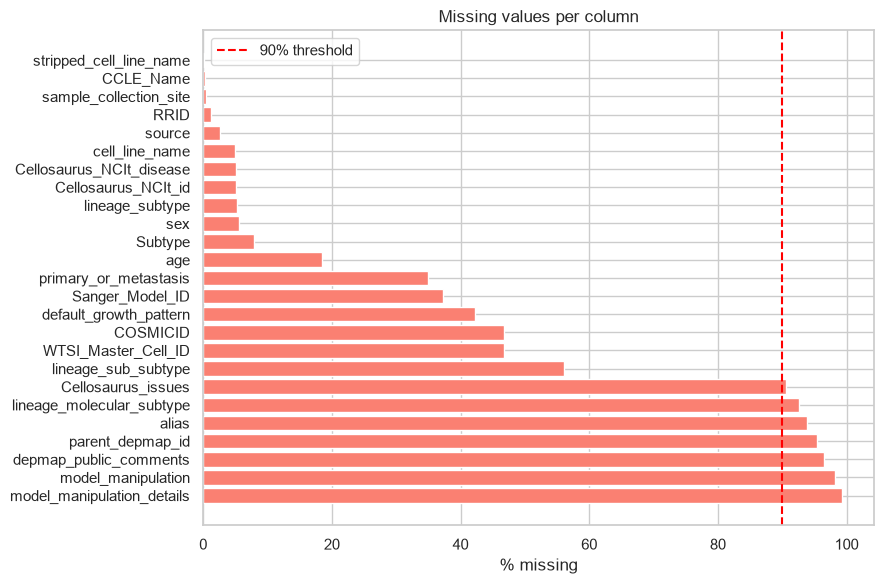

In [3]:
pct_missing = df.isnull().mean().sort_values(ascending=False) * 100
pct_missing = pct_missing[pct_missing > 0]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(pct_missing.index, pct_missing.values, color='salmon')
ax.axvline(90, color='red', linestyle='--', label='90% threshold')
ax.set_xlabel('% missing'); ax.set_title('Missing values per column'); ax.legend()
plt.tight_layout(); plt.show()

### Why this EDA check matters

Confirms `DepMap_ID` is a true primary key, and turns the missingness chart into an explicit
preprocessing decision: columns above 90% missing are drop candidates for `preprocess.py`, not
usable identity or context fields.

## 2. Lineage and disease composition

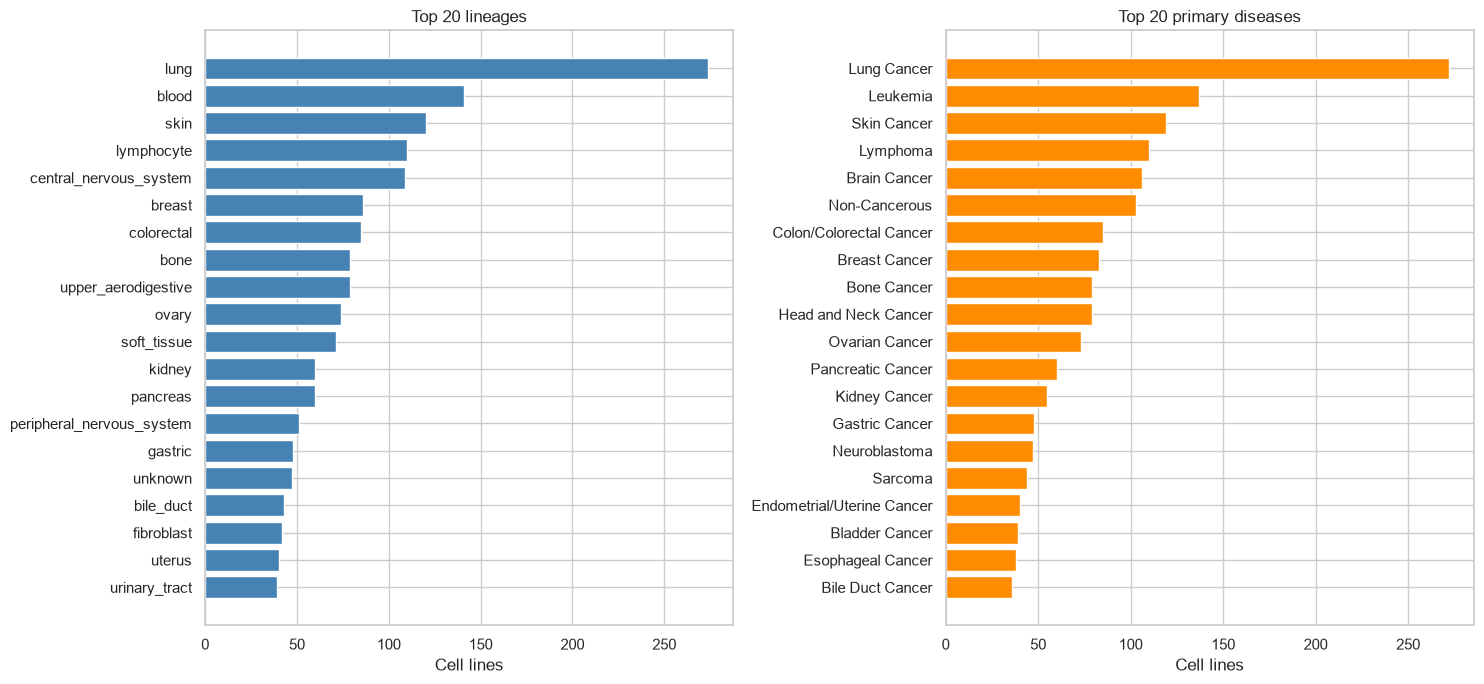

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
top_lineage = df['lineage'].value_counts().head(20)
axes[0].barh(top_lineage.index[::-1], top_lineage.values[::-1], color='steelblue')
axes[0].set_title('Top 20 lineages'); axes[0].set_xlabel('Cell lines')

top_disease = df['primary_disease'].value_counts().head(20)
axes[1].barh(top_disease.index[::-1], top_disease.values[::-1], color='darkorange')
axes[1].set_title('Top 20 primary diseases'); axes[1].set_xlabel('Cell lines')
plt.tight_layout(); plt.show()

### Why this EDA check matters

This is the real denominator for every "% of catalogue covered" number computed in notebooks
01–08. A lineage with few catalogued lines to begin with will always show sparse coverage in any
downstream layer, independent of that layer's own quality — the base rate has to be known first.

## 3. Clinical metadata confounds

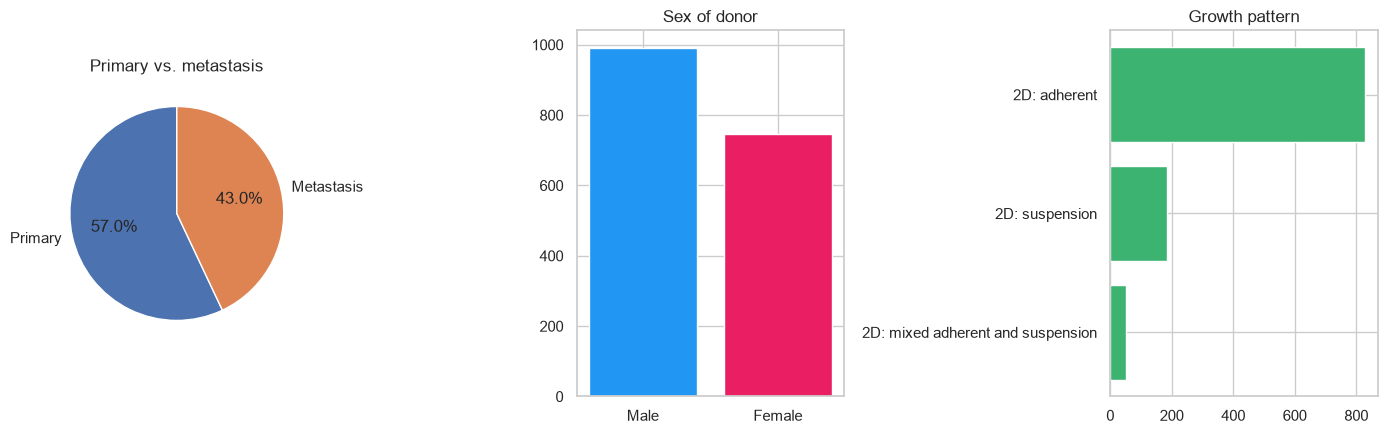

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pm = df['primary_or_metastasis'].value_counts()
axes[0].pie(pm.values, labels=pm.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Primary vs. metastasis')

sex = df['sex'].value_counts()
axes[1].bar(sex.index, sex.values, color=['#2196F3', '#E91E63', 'gray'])
axes[1].set_title('Sex of donor')

gp = df['default_growth_pattern'].value_counts()
axes[2].barh(gp.index[::-1], gp.values[::-1], color='mediumseagreen')
axes[2].set_title('Growth pattern')
plt.tight_layout(); plt.show()

### Why this EDA check matters

These are exactly the confounds root `_.md` §3/`docs/PROJECT_ARCHITECTURE.md` §1 warn must not be
silently pooled into a pan-cancer statement — a growth-pattern or primary/metastasis imbalance
within a lineage can look like a biological signal in a naive comparison when it is really a
sampling artefact of which cell lines happen to be catalogued.

## 4. Per-layer coverage of the spine, by lineage

In [6]:
df8 = pd.read_csv(NOMENCLATURE / '8_DepMap_OmicsProfiles.csv', usecols=['ProfileID', 'ModelID', 'Datatype'])
fusion_models = set(pd.read_csv(GENE_PROPERTIES / '5_OmicsFusionFilteredSupplementary.csv',
                                 usecols=['ModelID'])['ModelID'].dropna())
rna_models = set(df8[df8['Datatype'] == 'rna']['ModelID'])
mut_profiles = set(pd.read_csv(GENE_PROPERTIES / '6_OmicsSomaticMutationsProfile.csv',
                                usecols=['ProfileID'], low_memory=False)['ProfileID'].dropna())
mut_models = set(df8[(df8['Datatype'].isin(['wes', 'wgs'])) & (df8['ProfileID'].isin(mut_profiles))]['ModelID'])
sig_models = set(pd.read_csv(NON_GENE_EXPRESSION / '14_OmicsGlobalSignatures.csv',
                              usecols=['ModelID'])['ModelID'].dropna())

layers = {'RNA (file 2)': rna_models, 'Fusions (file 5)': fusion_models,
          'Mutations (file 6)': mut_models, 'Genome signatures (file 14)': sig_models}

lineage_df = df[['DepMap_ID', 'lineage']].dropna()
for name, models in layers.items():
    lineage_df[name] = lineage_df['DepMap_ID'].isin(models)

coverage_table = lineage_df.groupby('lineage')[list(layers)].mean().mul(100).round(0)
n_per_lineage = lineage_df['lineage'].value_counts()
coverage_table = coverage_table.loc[n_per_lineage.head(15).index]
coverage_table

,RNA (file 2),Fusions (file 5),Mutations (file 6),Genome signatures (file 14)
lineage,,,,
lung,77.0,78.0,92.0,92.0
blood,74.0,74.0,95.0,96.0
skin,72.0,72.0,91.0,92.0
lymphocyte,76.0,78.0,96.0,96.0
central_nervous_system,79.0,79.0,94.0,94.0
breast,73.0,74.0,79.0,79.0
colorectal,86.0,86.0,92.0,92.0
bone,51.0,54.0,86.0,87.0
upper_aerodigestive,72.0,73.0,95.0,96.0


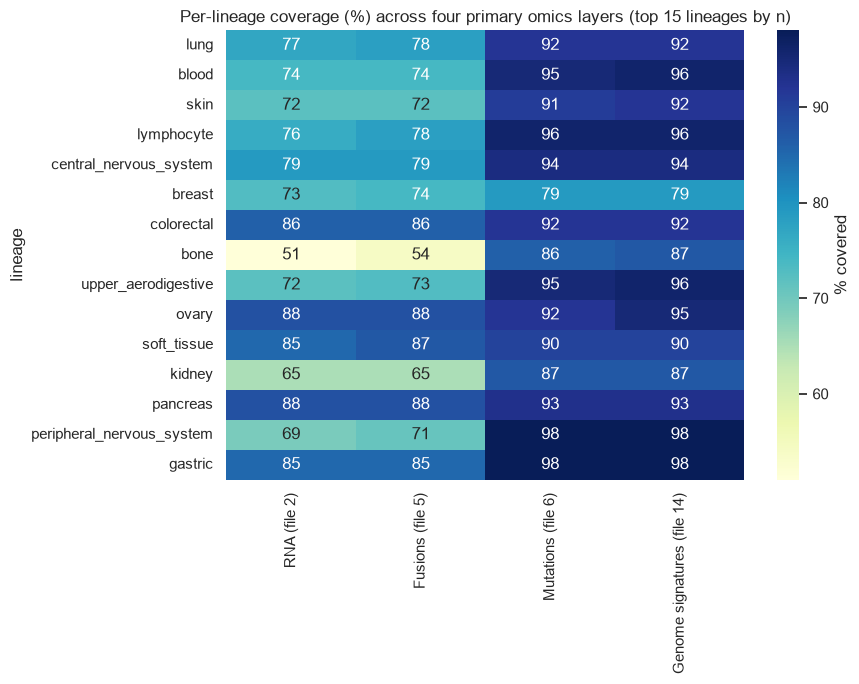

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(coverage_table, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': '% covered'}, ax=ax)
ax.set_title('Per-lineage coverage (%) across four primary omics layers (top 15 lineages by n)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

A lineage with strong metadata presence here but weak coverage across RNA/fusion/mutation/signature
layers will be under-represented in any multi-evidence score — not because the biology is unclear,
but because the assay simply was not run on enough of its lines. This heatmap is the concrete,
per-lineage version of the coverage bias check every notebook 01–08 ran in isolation, gathered
against the one shared denominator.

## Decisions carried into the next notebooks

1. **`DepMap_ID` is the canonical identity join hub** — every primary layer resolves to it, directly
   or via file 8.
2. This file carries the **legacy DepMap schema** — file 17 (notebook 17) is required to reconcile
   it against the modern `ModelID`/`OncotreeLineage` schema used by files 5/8/15/16.
3. Lineage and disease composition here (§2) is the real denominator for every coverage percentage
   computed elsewhere — a small catalogued lineage will always look sparsely covered.
4. Clinical metadata (primary/metastasis, sex, growth pattern) must be checked as a confound before
   any pan-cancer statistical claim (§3).
5. **Limitation:** the coverage heatmap in §4 uses only four of the primary layers as a
   representative sample, not the full 18-file audit — that full audit is a cross-layer notebook's
   job (`eda/cross_layer/01_coverage_and_join_audit`, not yet built).